In [ ]:
# 03_Model_Comparison_and_Advanced_EDA.ipynb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC

try:
    from xgboost import XGBClassifier
    xgb_available = True
except:
    xgb_available = False

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)


In [3]:
df = pd.read_csv("pcos_cleaned.csv")
df.head()


,age,weight,height,bmi,rbs,amh,lh,fsh,tsh,hirsutism,acne,irregular_cycle,follicle_l,follicle_r,pcos_label
0,28,44.6,152.0,19.300000,92.0,2.07,3.68,7.95,0.68,0.0,0.0,2,3,3,0
1,36,65.0,161.5,24.921163,92.0,1.53,1.09,6.73,3.16,0.0,0.0,2,3,5,0
2,33,68.8,165.0,25.270891,84.0,6.63,0.88,5.54,2.54,0.0,1.0,2,13,15,1
3,37,65.0,148.0,29.674945,76.0,1.22,2.36,8.06,16.41,0.0,0.0,2,2,2,0
4,25,52.0,161.0,20.060954,84.0,2.26,0.90,3.98,3.57,0.0,0.0,2,3,4,0


In [ ]:
print("Shape:", df.shape)
df.info()

Shape: (541, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              541 non-null    int64  
 1   weight           541 non-null    float64
 2   height           541 non-null    float64
 3   bmi              541 non-null    float64
 4   rbs              541 non-null    float64
 5   amh              541 non-null    float64
 6   lh               541 non-null    float64
 7   fsh              541 non-null    float64
 8   tsh              541 non-null    float64
 9   hirsutism        541 non-null    float64
 10  acne             541 non-null    float64
 11  irregular_cycle  541 non-null    int64  
 12  follicle_l       541 non-null    int64  
 13  follicle_r       541 non-null    int64  
 14  pcos_label       541 non-null    int64  
dtypes: float64(10), int64(5)
memory usage: 63.5 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,541.0,31.430684,5.411006,20.000000,28.000000,31.000000,35.000000,48.0
weight,541.0,59.637153,11.028287,31.000000,52.000000,59.000000,65.000000,108.0
height,541.0,156.484835,6.033545,137.000000,152.000000,156.000000,160.000000,180.0
bmi,541.0,24.311285,4.056399,12.417882,21.641274,24.238227,26.634958,38.9
rbs,541.0,99.835860,18.559298,60.000000,92.000000,100.000000,107.000000,350.0
amh,541.0,5.620634,5.876742,0.100000,2.010000,3.700000,6.900000,66.0
lh,541.0,6.469919,86.673255,0.020000,1.020000,2.300000,3.680000,2018.0
fsh,541.0,14.601832,217.022081,0.210000,3.300000,4.850000,6.410000,5052.0
tsh,541.0,2.981281,3.755532,0.040000,1.480000,2.260000,3.570000,65.0
hirsutism,541.0,0.273567,0.446202,0.000000,0.000000,0.000000,1.000000,1.0


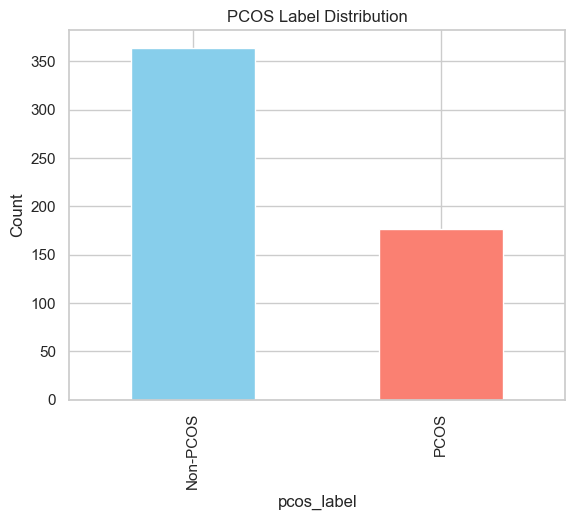

In [7]:
df["pcos_label"].value_counts().plot(kind='bar', color=["skyblue", "salmon"])
plt.title("PCOS Label Distribution")
plt.xticks([0,1], ["Non-PCOS", "PCOS"])
plt.ylabel("Count")
plt.show()


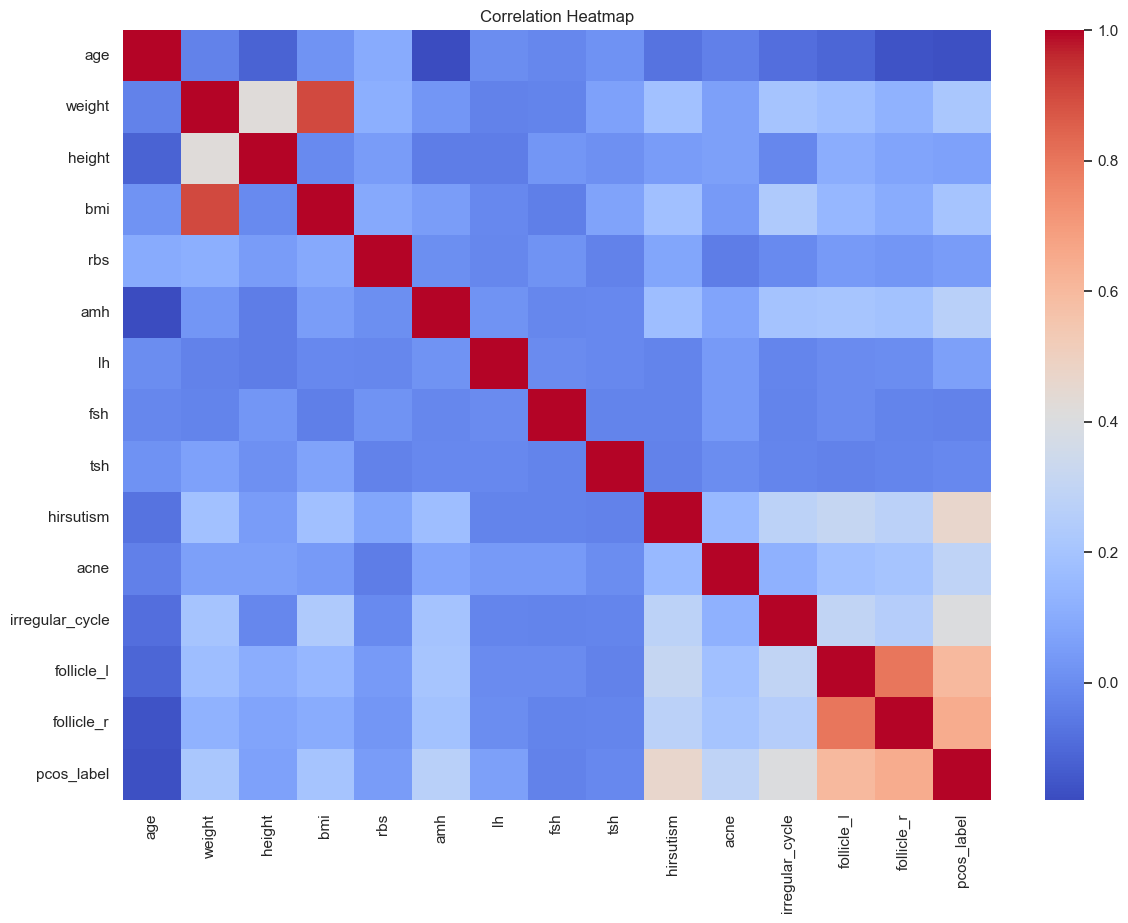

In [8]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [9]:
corr = df.corr()["pcos_label"].abs().sort_values(ascending=False)
corr


pcos_label         1.000000
follicle_r         0.648327
follicle_l         0.603346
hirsutism          0.464667
irregular_cycle    0.401644
acne               0.286077
amh                0.264141
weight             0.211938
bmi                0.199534
age                0.168513
height             0.068254
lh                 0.063879
rbs                0.048922
fsh                0.030319
tsh                0.010140
Name: pcos_label, dtype: float64

In [ ]:
threshold = 0.05
important_features = corr[corr > threshold].index.tolist()
important_features.remove("pcos_label")

print("Important Features:", important_features)

X = df[important_features]
y = df["pcos_label"]

Important Features: ['follicle_r', 'follicle_l', 'hirsutism', 'irregular_cycle', 'acne', 'amh', 'weight', 'bmi', 'age', 'height', 'lh']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [12]:
num_cols = X.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols)
    ]
)


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=300),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "AdaBoost": AdaBoostClassifier(
        n_estimators=300,
        learning_rate=0.5,
        random_state=42
    ),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=42)
}


In [16]:
def evaluate_model(name, model):
    pipe = Pipeline([
        ("pre", preprocessor),
        ("clf", model)
    ])

    pipe.fit(X_train, y_train)

    preds = pipe.predict(X_test)
    probs = pipe.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)

    print(f"\n{name} Results")
    print("-" * 30)
    print("Accuracy:", acc)
    print("F1 Score:", f1)
    print("ROC-AUC:", auc)
    print("\nClassification Report:")
    print(classification_report(y_test, preds))

    # Confusion Matrix
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return acc, f1, auc



Logistic Regression Results
------------------------------
Accuracy: 0.9174311926605505
F1 Score: 0.8732394366197183
ROC-AUC: 0.9463470319634705

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94        73
           1       0.89      0.86      0.87        36

    accuracy                           0.92       109
   macro avg       0.91      0.90      0.91       109
weighted avg       0.92      0.92      0.92       109



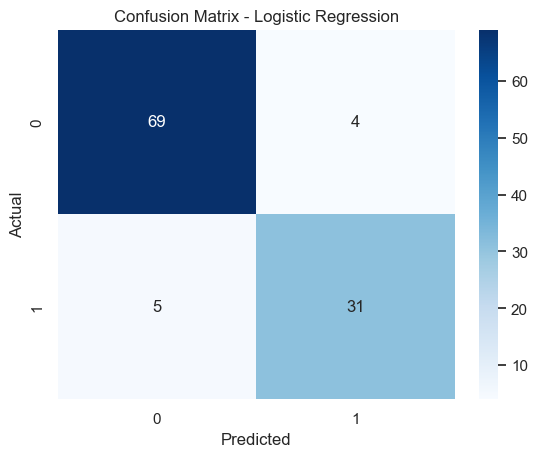


Random Forest Results
------------------------------
Accuracy: 0.908256880733945
F1 Score: 0.8571428571428571
ROC-AUC: 0.9404490106544902

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.95      0.93        73
           1       0.88      0.83      0.86        36

    accuracy                           0.91       109
   macro avg       0.90      0.89      0.89       109
weighted avg       0.91      0.91      0.91       109



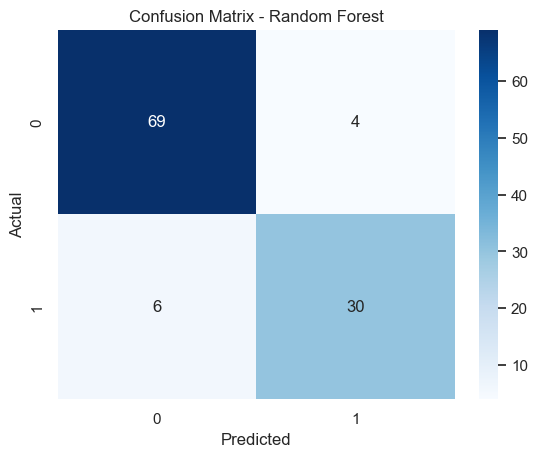

c:\Users\Medha Kauluri\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(



AdaBoost Results
------------------------------
Accuracy: 0.8990825688073395
F1 Score: 0.8450704225352113
ROC-AUC: 0.9410197869101979

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.93      0.93        73
           1       0.86      0.83      0.85        36

    accuracy                           0.90       109
   macro avg       0.89      0.88      0.89       109
weighted avg       0.90      0.90      0.90       109



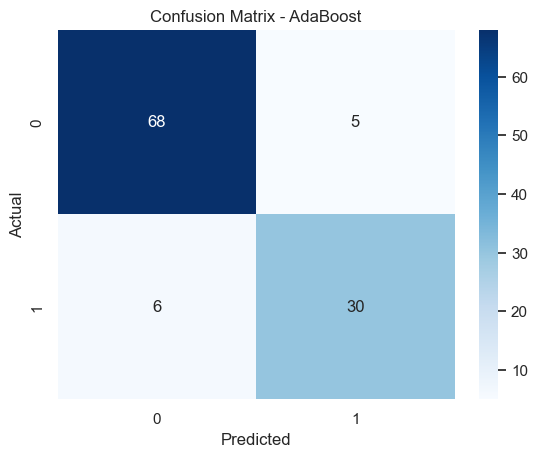


SVM (RBF) Results
------------------------------
Accuracy: 0.908256880733945
F1 Score: 0.8611111111111112
ROC-AUC: 0.952054794520548

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        73
           1       0.86      0.86      0.86        36

    accuracy                           0.91       109
   macro avg       0.90      0.90      0.90       109
weighted avg       0.91      0.91      0.91       109



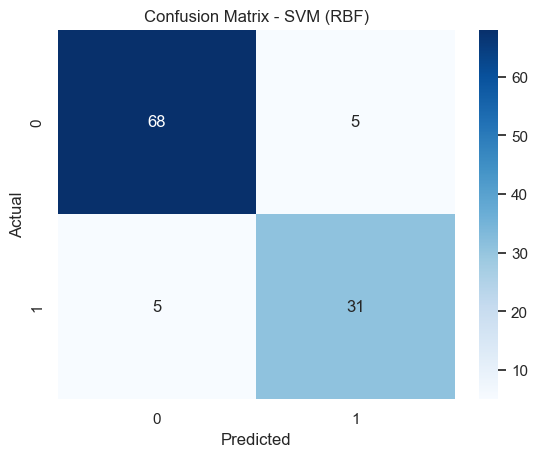

,Accuracy,F1,AUC
Logistic Regression,0.917431,0.873239,0.946347
Random Forest,0.908257,0.857143,0.940449
AdaBoost,0.899083,0.845070,0.941020
SVM (RBF),0.908257,0.861111,0.952055


In [15]:
results = {}

for name, model in models.items():
    acc, f1, auc = evaluate_model(name, model)
    results[name] = {"Accuracy": acc, "F1": f1, "AUC": auc}

results_df = pd.DataFrame(results).T
results_df


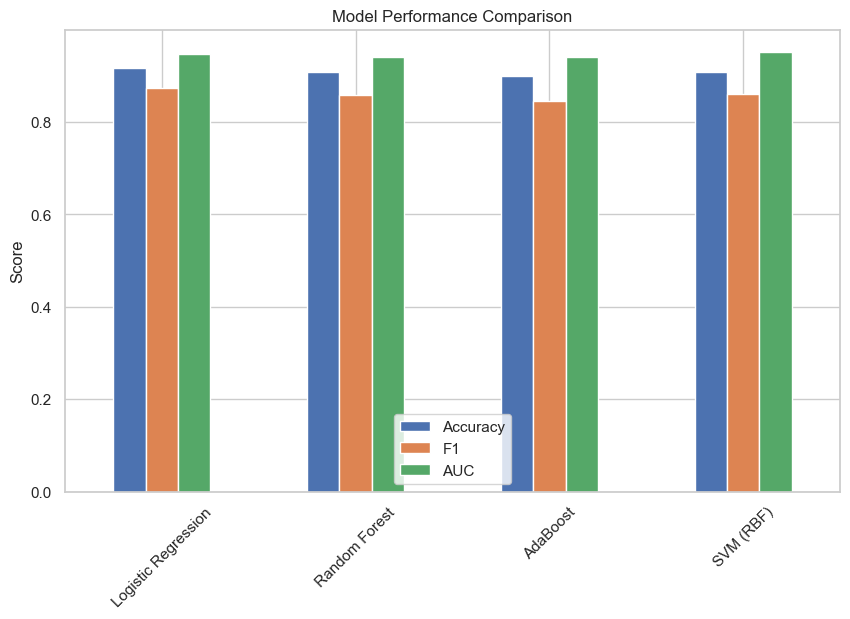

In [17]:
results_df.plot(kind="bar", figsize=(10,6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()


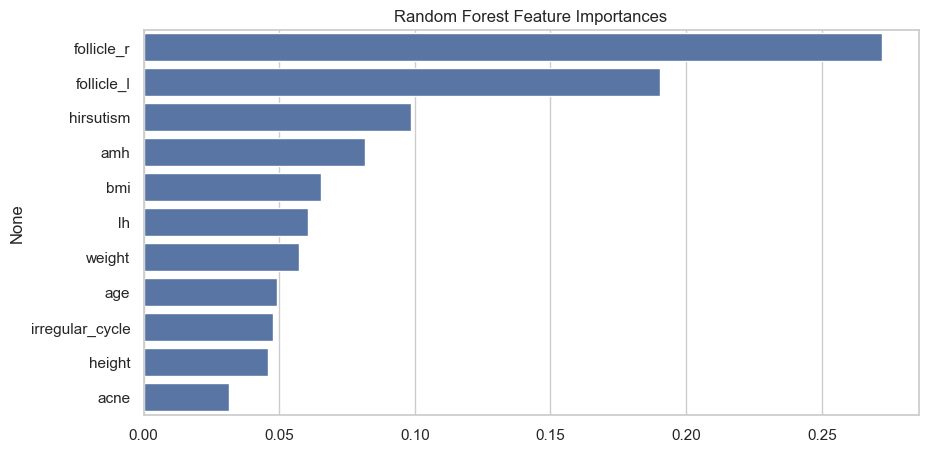

follicle_r         0.272029
follicle_l         0.190482
hirsutism          0.098544
amh                0.081685
bmi                0.065385
lh                 0.060508
weight             0.057238
age                0.049045
irregular_cycle    0.047629
height             0.045958
acne               0.031495
dtype: float64

In [18]:
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Random Forest Feature Importances")
plt.show()

importances


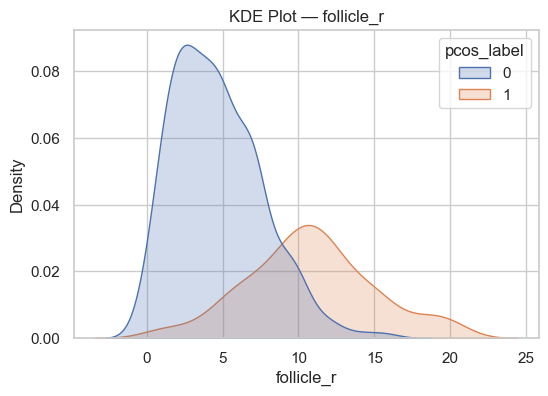

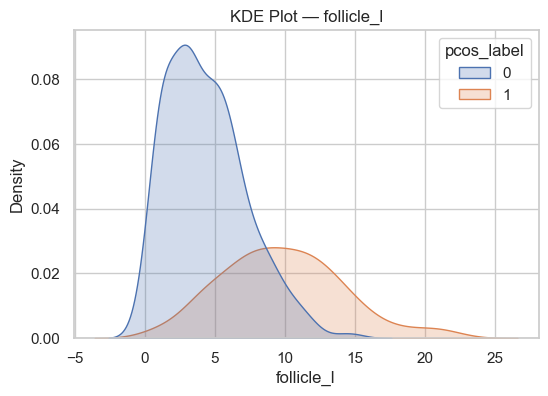

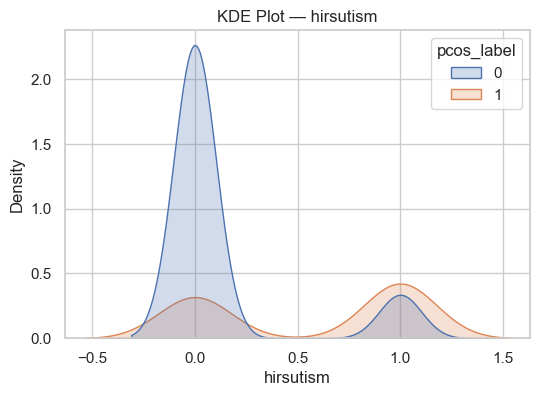

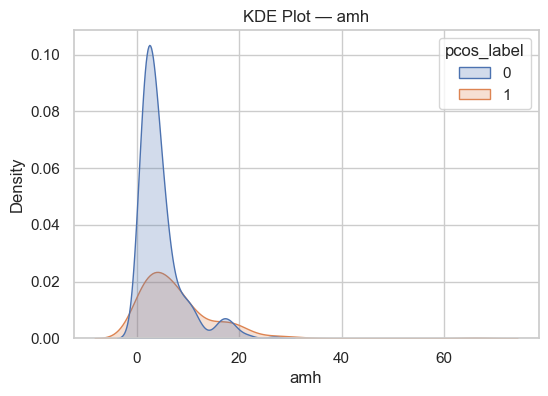

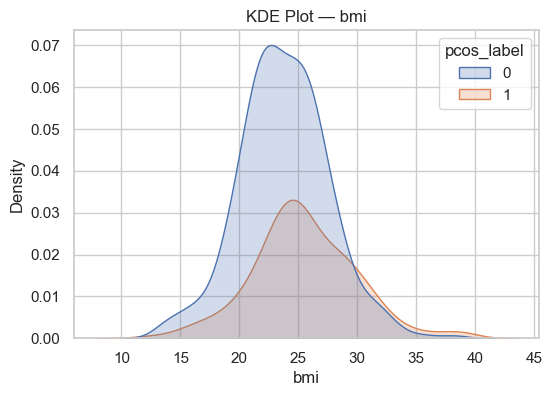

In [19]:
top_features = importances.index[:5]

for col in top_features:
    plt.figure(figsize=(6,4))
    sns.kdeplot(data=df, x=col, hue="pcos_label", fill=True)
    plt.title(f"KDE Plot — {col}")
    plt.show()


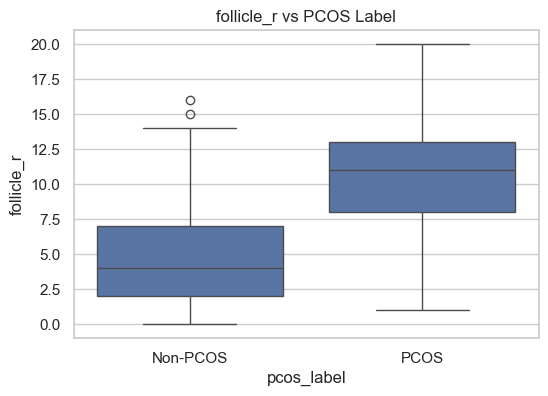

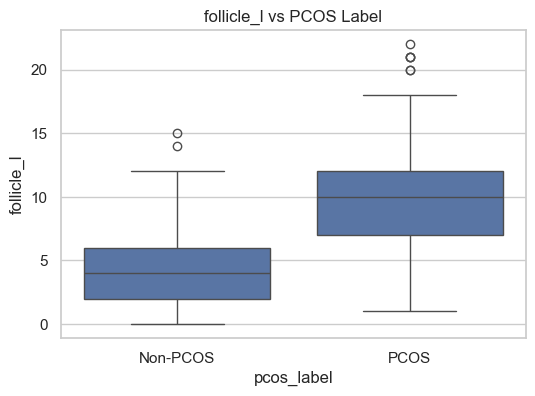

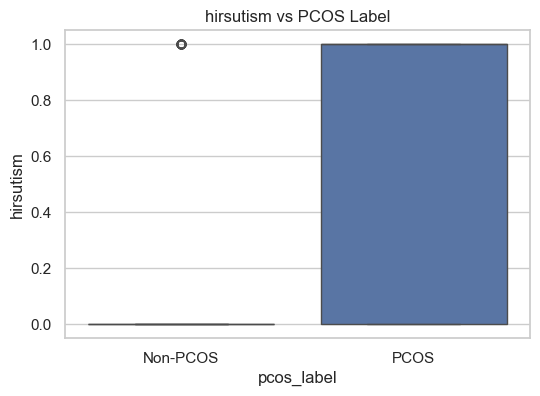

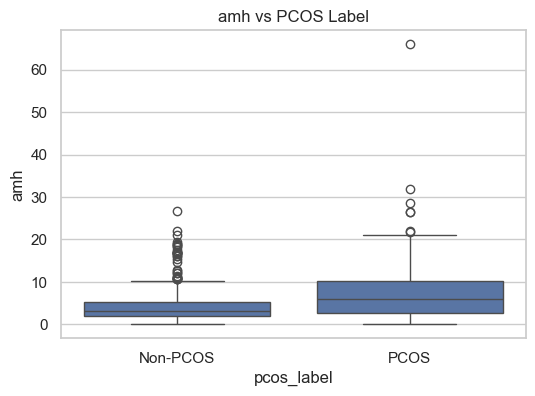

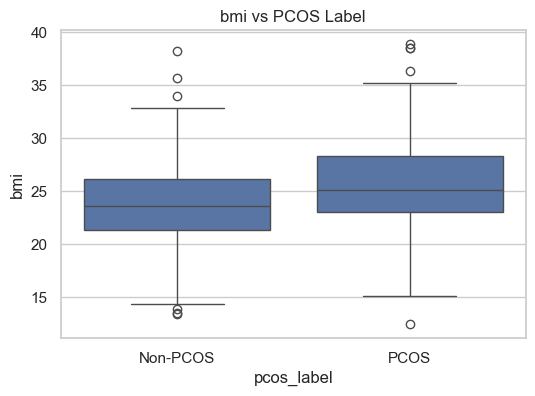

In [20]:
for col in top_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df["pcos_label"], y=df[col])
    plt.title(f"{col} vs PCOS Label")
    plt.xticks([0,1], ["Non-PCOS", "PCOS"])
    plt.show()


In [22]:
df_selected = df[important_features + ["pcos_label"]]
df_selected.to_csv("pcos_selected_features.csv", index=False)
"Saved!"


'Saved!'

In [ ]:
# ============================
# PCOS PREDICTION FULL PIPELINE
# ONE-CELL IMPLEMENTATION
# ============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
import joblib

# ============================
# 1. LOAD DATA
# ============================

df = pd.read_excel("PCOS_data_without_infertility.xlsx")

# Remove unwanted columns
drop_cols = ['Sl. No', 'Patient File No', 'Unnamed: 44']
for col in drop_cols:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

# Recalculate BMI if needed
if "Weight (Kg)" in df.columns and "Height(Cm)" in df.columns:
    df["BMI"] = df["Weight (Kg)"] / ((df["Height(Cm)"] / 100) ** 2)

# Fill missing values
df = df.fillna(df.median())

# ============================
# 2. FEATURE SELECTION
# ============================

selected_features = [
    'Age', 'BMI', 'Cycle length', 'AMH(ng/mL)', 'LH(mIU/mL)', 'FSH(mIU/mL)',
    'Follicle No. (L)', 'Follicle No. (R)', 'Avg F size (L)', 'Avg F size (R)',
    'Irregular_Menstruation', 'Hair_Growth', 'Skin_Darkening'
]

selected_features = [f for f in selected_features if f in df.columns]

X = df[selected_features]
y = df['PCOS (Y/N)']

# ============================
# 3. TRAIN TEST SPLIT
# ============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ============================
# 4. SCALING
# ============================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================
# 5. MODEL TRAINING
# ============================

models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "SVM": SVC(probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=200, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob),
        "Confusion Matrix": confusion_matrix(y_test, y_pred)
    }

# ============================
# 6. DISPLAY RESULTS
# ============================

for name, metrics in results.items():
    print(f"\n===== {name} =====")
    print("Accuracy:", round(metrics["Accuracy"], 4))
    print("F1 Score:", round(metrics["F1 Score"], 4))
    print("AUC:", round(metrics["AUC"], 4))
    print("Confusion Matrix:\n", metrics["Confusion Matrix"])

# ============================
# 7. SAVE BEST MODEL
# ============================

best_model = max(results, key=lambda m: results[m]["Accuracy"])
final_model = models[best_model]

joblib.dump(final_model, "pcos_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("\nBest Model Saved:", best_model)
